# EDA - Explratory
Análisis exploratorio de datos año por año.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Agregar raiz al Path
current_dir = Path.cwd().resolve()
for parent in current_dir.parents:
    if (parent / "config.py").exists():
        sys.path.insert(0, str(parent))
        break

from config import (
    ANIOS_PROCESAR,
    PROCESSED_PATHS,
    logger,
)

### Carga y Explarión de estructura

In [2]:
resumen_anios = {}

for anio in ANIOS_PROCESAR:
    try:
        df = pd.read_parquet(PROCESSED_PATHS[f"consolidated_{anio}"])
        
        resumen_anios[anio] = {
            'filas': len(df),
            'columnas': df.shape[1],
            'memoria_mb': df.memory_usage(deep=True).sum() / (1024**2),
            'tipos': df.dtypes.value_counts().to_dict()
        }
        
        print(f"\n AÑO {anio}")
        print(f"  Filas: {len(df):,}")
        print(f"  Columnas: {df.shape[1]}")
        print(f"  Memoria: {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")
        print(f"  Tipos de datos: {df.dtypes.nunique()} únicos")
    except Exception as e:
        print(f"   Error: {e}")


 AÑO 2022
  Filas: 1,731,201
  Columnas: 70
  Memoria: 1655.85 MB
  Tipos de datos: 4 únicos

 AÑO 2023
  Filas: 2,029,314
  Columnas: 70
  Memoria: 2427.57 MB
  Tipos de datos: 4 únicos

 AÑO 2024
  Filas: 2,194,444
  Columnas: 70
  Memoria: 2580.36 MB
  Tipos de datos: 4 únicos

 AÑO 2025
  Filas: 2,231,647
  Columnas: 70
  Memoria: 2597.86 MB
  Tipos de datos: 4 únicos

 AÑO 2026
  Filas: 1,347,972
  Columnas: 70
  Memoria: 1540.75 MB
  Tipos de datos: 4 únicos


### Gráfico: Evoluciónde tamaño por año

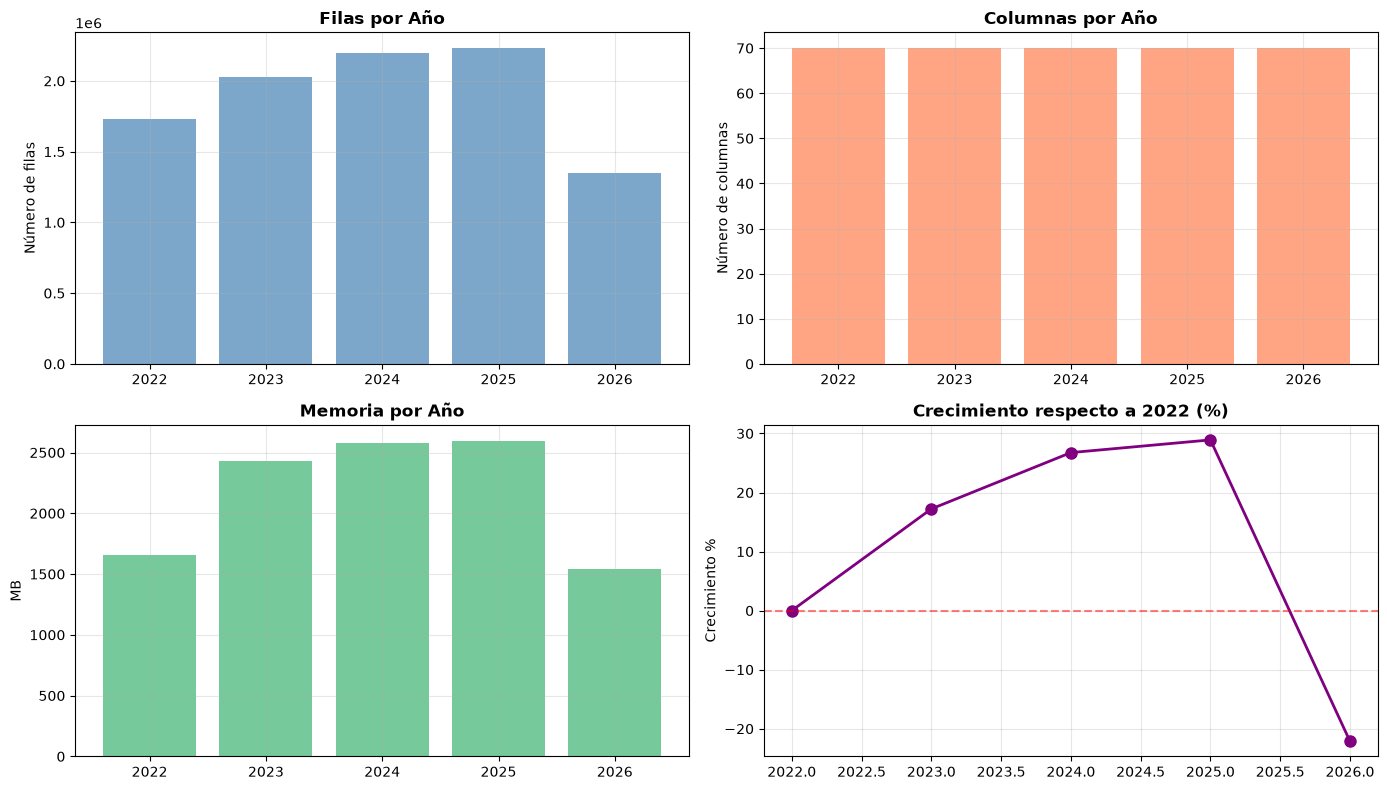

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Filas por año
anios = list(resumen_anios.keys())
filas = [resumen_anios[a]['filas'] for a in anios]
axes[0, 0].bar(anios, filas, color='steelblue', alpha=0.7)
axes[0, 0].set_title('Filas por Año', fontweight='bold')
axes[0, 0].set_ylabel('Número de filas')
axes[0, 0].grid(alpha=0.3)

# Columnas por año
columnas = [resumen_anios[a]['columnas'] for a in anios]
axes[0, 1].bar(anios, columnas, color='coral', alpha=0.7)
axes[0, 1].set_title('Columnas por Año', fontweight='bold')
axes[0, 1].set_ylabel('Número de columnas')
axes[0, 1].grid(alpha=0.3)

# Memoria por año
memoria = [resumen_anios[a]['memoria_mb'] for a in anios]
axes[1, 0].bar(anios, memoria, color='mediumseagreen', alpha=0.7)
axes[1, 0].set_title('Memoria por Año', fontweight='bold')
axes[1, 0].set_ylabel('MB')
axes[1, 0].grid(alpha=0.3)

# Resumen de crecimiento
crecimiento = [(filas[i]/filas[0] - 1) * 100 for i in range(len(filas))]
axes[1, 1].plot(anios, crecimiento, marker='o', linewidth=2, markersize=8, color='purple')
axes[1, 1].set_title('Crecimiento respecto a 2022 (%)', fontweight='bold')
axes[1, 1].set_ylabel('Crecimiento %')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Análisis de nulos
Devuelve por año las columnas con nulos ordenadas por cantidad

In [4]:
for anio in ANIOS_PROCESAR:
    try:
        df = pd.read_parquet(PROCESSED_PATHS[f"consolidated_{anio}"])

        nulos = df.isnull().sum()
        nulos_pct = (nulos / len(df)) * 100

        if nulos.sum() == 0:
            print(f"\n Año {anio} sin nulos")
            continue

        print(f"\n - {anio}: {nulos.sum():,} nulos encontrados")

        cols_con_nulos = nulos[nulos > 0].sort_values(ascending=False)
        for col in cols_con_nulos.index:
            porcentaje = nulos_pct[col]
            print(f" - {col:35s} {nulos[col]:7,} ({porcentaje:5.1f}%)")
       
        
    except Exception as e:
        print(f" Error: {e}")


 - 2022: 51,602,453 nulos encontrados
 - hora_apertura2                      1,728,250 ( 99.8%)
 - hora_cierre2                        1,728,050 ( 99.8%)
 - hora_cierre1                        1,707,744 ( 98.6%)
 - hora_apertura1                      1,699,768 ( 98.2%)
 - coordenada_y_agrupacion             1,683,043 ( 97.2%)
 - coordenada_y_agrup_y                1,614,151 ( 93.2%)
 - coordenada_y_agrup_x                1,614,139 ( 93.2%)
 - coordenada_x_agrupacion             1,565,981 ( 90.5%)
 - desc_division_y                     1,550,948 ( 89.6%)
 - desc_epigrafe                       1,550,948 ( 89.6%)
 - desc_division_x                     1,550,948 ( 89.6%)
 - id_seccion_x                        1,550,948 ( 89.6%)
 - id_epigrafe_y                       1,550,948 ( 89.6%)
 - id_epigrafe_x                       1,550,948 ( 89.6%)
 - id_seccion_y                        1,550,948 ( 89.6%)
 - desc_seccion_x                      1,550,948 ( 89.6%)
 - desc_seccion_y                

### Gráfico: Columnas con más nulos por año

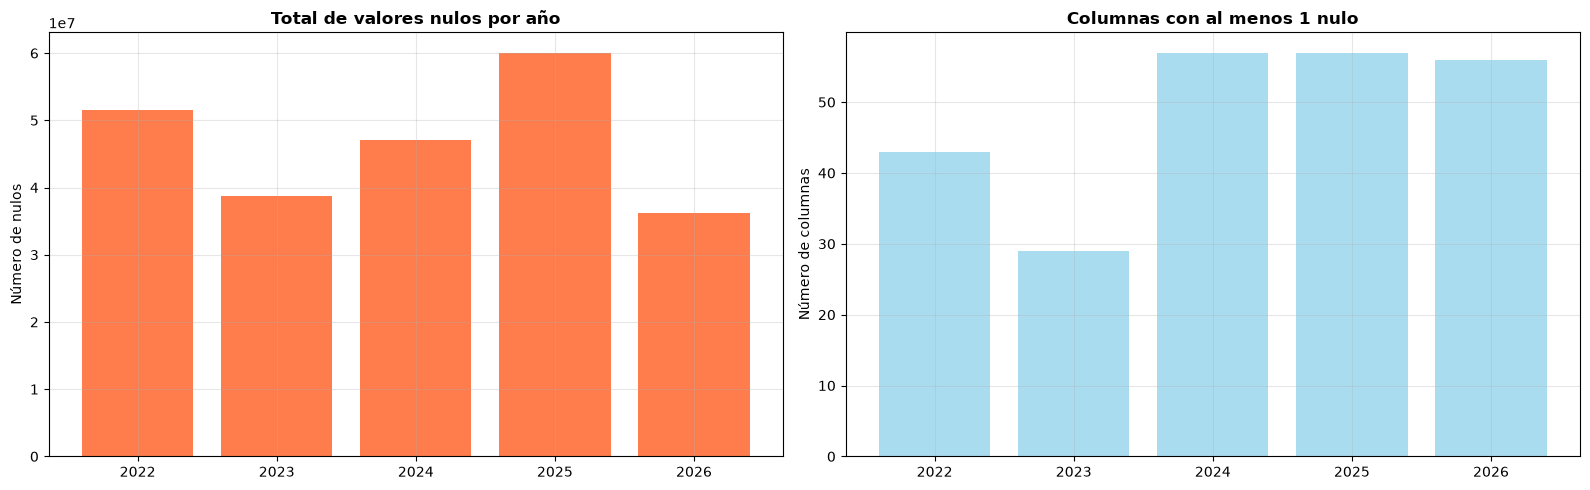

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico izquierda: Total de nulos por año
nulos_totales_por_anio = []
for anio in ANIOS_PROCESAR:
    df = pd.read_parquet(PROCESSED_PATHS[f"consolidated_{anio}"])
    nulos_totales_por_anio.append(df.isnull().sum().sum())

axes[0].bar(ANIOS_PROCESAR, nulos_totales_por_anio, color='orangered', alpha=0.7)
axes[0].set_title('Total de valores nulos por año', fontweight='bold')
axes[0].set_ylabel('Número de nulos')
axes[0].grid(alpha=0.3)

# Gráfico derecha: Columnas con nulos por año
cols_con_nulos = []
for anio in ANIOS_PROCESAR:
    df = pd.read_parquet(PROCESSED_PATHS[f"consolidated_{anio}"])
    cols_con_nulos.append((df.isnull().sum() > 0).sum())

axes[1].bar(ANIOS_PROCESAR, cols_con_nulos, color='skyblue', alpha=0.7)
axes[1].set_title('Columnas con al menos 1 nulo', fontweight='bold')
axes[1].set_ylabel('Número de columnas')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Análisis de duplicados

In [6]:
for anio in ANIOS_PROCESAR:
    try:
        df = pd.read_parquet(PROCESSED_PATHS[f"consolidated_{anio}"])

        duplicados_totales = df.duplicated().sum()
        duplicados_id = df.duplicated(subset=['local_id']).sum() if 'local_id' in df.columns else 0

        print(f"\n- {anio}")
        print(f"Filas duplicadas (todas las columnas): {duplicados_totales:,}")
        if 'local_id' in df.columns:
            print(f" Locales duplicados por ID: {duplicados_id:,}")
        
    except Exception as e:
        print(f" Error: {e}")


- 2022
Filas duplicadas (todas las columnas): 0
 Locales duplicados por ID: 1,580,635

- 2023
Filas duplicadas (todas las columnas): 0
 Locales duplicados por ID: 1,878,134

- 2024
Filas duplicadas (todas las columnas): 0
 Locales duplicados por ID: 1,993,183

- 2025
Filas duplicadas (todas las columnas): 0
 Locales duplicados por ID: 2,028,755

- 2026
Filas duplicadas (todas las columnas): 0
 Locales duplicados por ID: 1,144,642


### Tipos de Datos

In [7]:
for anio in ANIOS_PROCESAR:
    try:
        df = pd.read_parquet(PROCESSED_PATHS[f"consolidated_{anio}"])

        print(f"\n - {anio}")
        tipos = df.dtypes.value_counts()
        for tipo, cantidad in tipos.items():
            print(f" {str(tipo):20s} {cantidad:3d} columnas")
  
    except Exception as e:
        print(f" Error: {e}")


 - 2022
 str                   46 columnas
 int64                 11 columnas
 float64               10 columnas
 string                 3 columnas

 - 2023
 str                   33 columnas
 int64                 20 columnas
 object                13 columnas
 float64                4 columnas

 - 2024
 str                   33 columnas
 float64               17 columnas
 object                13 columnas
 int64                  7 columnas

 - 2025
 str                   30 columnas
 float64               17 columnas
 object                16 columnas
 int64                  7 columnas

 - 2026
 str                   30 columnas
 float64               17 columnas
 object                16 columnas
 int64                  7 columnas


### Análisis de columnas claves

In [8]:
for anio in ANIOS_PROCESAR:
    try:
        df = pd.read_parquet(PROCESSED_PATHS[f"consolidated_{anio}"])

        print(f"\n {anio}")

        # local_id
        if 'local_id' in df.columns:
            print(f"\n local_id:")
            print(f"    - Únicos: {df['local_id'].nunique():,}")
            print(f"    - Nulos: {df['local_id'].isnull().sum():,}")
            print(f"    - Tipos: {df['local_id'].dtype}")

        # fecha
        if 'fecha' in df.columns:
            print(f"\n fecha:")
            print(f"    - Única: {df['fecha'].nunique():,}")
            print(f"    - Rango: {df['fecha'].min()} -> {df['fecha'].max()}")
            print(f"    - Nulos: {df['fecha'].isnull().sum():,}")
            
        #desc_barrio_local
        if 'desc_barrio_local' in df.columns:
            print(f"\n desc_barrio_local (BARRIOS)")
            print(f"    - Únicos: {df['desc_barrio_local'].nunique():,}")
            print(f"    - Nulos: {df['desc_barrio_local'].isnull().sum():,}")
            print(f"    - Top 5:")
            for barrio, count in df['desc_barrio_local'].value_counts().head(5).items():
                print(f"    - {barrio}: {count:,}")

        # descripcion_actividad
        if 'descripcion_actividad' in df.columns:
            nulos_act = df['descripcion_actividad'].isnull().sum()
            print(f"\n descripcion_actividad")
            print(f"    - Únicos: {df['descripcion_actividad'].nunique():,}")
            print(f"    - Nulos: {nulos_act:,} ({nulos_act/len(df)*100:.1f}%)")
            print(f"    - Top 5")
            for act, count in df['descripcion_actividad'].value_counts().head(5).items():
                act_short = str(act)[:40] if pd.notna(act) else "NULL"
                print(f"    - {act_short}: {count:,}")

        # id_epigrafe
        if 'id_epigrafe' in df.columns:
            print(f"\n id_epigrafe")
            print(f"    - Únicos: {df['id_epigrafe'].nunique():,}")
            print(f"    - Nulos: {df['id_epigrafe'].isnull().sum():,}")
            
    except Exception as e:
        print(f" Error: {e}")


 2022

 local_id:
    - Únicos: 150,566
    - Nulos: 0
    - Tipos: int64

 fecha:
    - Única: 10


    - Rango: 202202 -> 202212
    - Nulos: 0

 desc_barrio_local (BARRIOS)
    - Únicos: 131
    - Nulos: 0
    - Top 5:
    - SAN ANDRES          : 45,669
    - CASCO H.VALLECAS    : 41,771
    - EMBAJADORES         : 41,328
    - PUEBLO NUEVO        : 37,644
    - VISTA ALEGRE        : 35,403

 descripcion_actividad
    - Únicos: 447
    - Nulos: 273,514 (15.8%)
    - Top 5
    - VALOR NULO EN ORIGEN: 117,034
    - SERVICIO DE PELUQUERIA: 56,229
    - BAR CON COCINA: 46,076
    - BAR RESTAURANTE: 45,589
    - COMERCIO AL POR MENOR DE PRENDAS DE VEST: 42,012

 id_epigrafe
    - Únicos: 451
    - Nulos: 453,767

 2023

 local_id:
    - Únicos: 151,180
    - Nulos: 0
    - Tipos: int64

 fecha:
    - Única: 12
    - Rango: 202301 -> 202312
    - Nulos: 0

 desc_barrio_local (BARRIOS)
    - Únicos: 132
    - Nulos: 0
    - Top 5:
    - SAN ANDRES          : 53,763
    - CASCO H.VALLECAS    : 49,133
    - EMBAJADORES         : 48,333
    - PUEBLO NUEVO        : 44,512
    - VISTA ALEGRE  

In [9]:
print("\n📊 CARACTERÍSTICAS CLAVE POR AÑO\n")

features_data = {anio: {} for anio in ANIOS_PROCESAR}

for anio in ANIOS_PROCESAR:
    try:
        df = pd.read_parquet(PROCESSED_PATHS[f"consolidated_{anio}"])
        
        print(f"  {anio}:")
        
        if 'local_id' in df.columns:
            unique_locals = df['local_id'].nunique()
            features_data[anio]['locales'] = unique_locals
            print(f"    Locales únicos: {unique_locals:,}")
        
        if 'desc_barrio_local' in df.columns:
            barrios = df['desc_barrio_local'].nunique()
            features_data[anio]['barrios'] = barrios
            print(f"    Barrios: {barrios}")
        
        if 'desc_distrito_local' in df.columns:
            distritos = df['desc_distrito_local'].nunique()
            features_data[anio]['distritos'] = distritos
            print(f"    Distritos: {distritos}")
        
        if 'fecha' in df.columns:
            meses = df['fecha'].nunique()
            features_data[anio]['meses'] = meses
            print(f"    Meses cubiertos: {meses}")
            
    except Exception as e:
        print(f"    ❌ Error: {e}")


📊 CARACTERÍSTICAS CLAVE POR AÑO

  2022:
    Locales únicos: 150,566
    Barrios: 131
    Distritos: 21
    Meses cubiertos: 10
  2023:
    Locales únicos: 151,180
    Barrios: 132
    Distritos: 21
    Meses cubiertos: 12
  2024:
    Locales únicos: 201,261
    Barrios: 131
    Distritos: 21
    Meses cubiertos: 12
  2025:
    Locales únicos: 202,892
    Barrios: 131
    Distritos: 21
    Meses cubiertos: 10
  2026:
    Locales únicos: 203,330
    Barrios: 131
    Distritos: 21
    Meses cubiertos: 6


### Gráfico: Cobertura geográfica y temporal

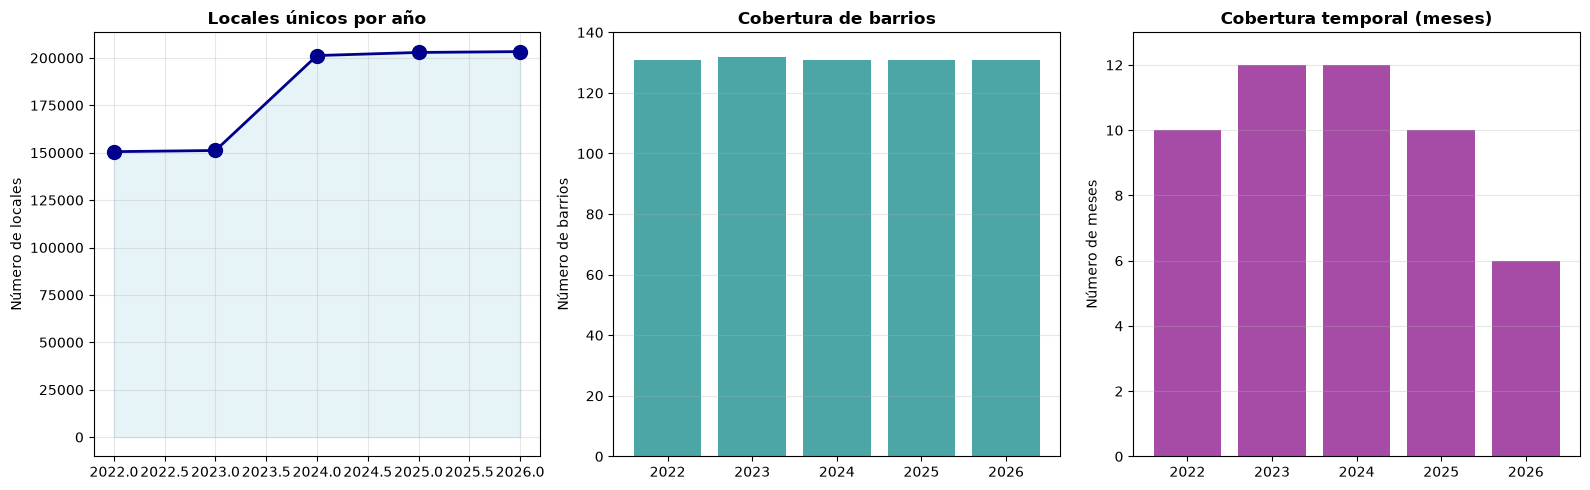

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Locales únicos
locales = [features_data[a].get('locales', 0) for a in ANIOS_PROCESAR]
axes[0].plot(ANIOS_PROCESAR, locales, marker='o', linewidth=2, markersize=10, color='darkblue')
axes[0].fill_between(ANIOS_PROCESAR, locales, alpha=0.3, color='lightblue')
axes[0].set_title('Locales únicos por año', fontweight='bold')
axes[0].set_ylabel('Número de locales')
axes[0].grid(alpha=0.3)

# Barrios
barrios = [features_data[a].get('barrios', 0) for a in ANIOS_PROCESAR]
axes[1].bar(ANIOS_PROCESAR, barrios, color='teal', alpha=0.7)
axes[1].set_title('Cobertura de barrios', fontweight='bold')
axes[1].set_ylabel('Número de barrios')
axes[1].grid(alpha=0.3, axis='y')
axes[1].set_ylim([0, 140])

# Meses cubiertos
meses = [features_data[a].get('meses', 0) for a in ANIOS_PROCESAR]
axes[2].bar(ANIOS_PROCESAR, meses, color='purple', alpha=0.7)
axes[2].set_title('Cobertura temporal (meses)', fontweight='bold')
axes[2].set_ylabel('Número de meses')
axes[2].grid(alpha=0.3, axis='y')
axes[2].set_ylim([0, 13])

plt.tight_layout()
plt.show()

### Problemas de encoding

In [11]:


for anio in ANIOS_PROCESAR:
    try:
        df = pd.read_parquet(PROCESSED_PATHS[f"consolidated_{anio}"])
        
        problemas = 0
        cols_problema = {}
        
        # Detectar caracteres problemáticos en strings
        for col in df.select_dtypes(include=['object', 'string']).columns:
            valores_str = df[col].astype(str)
            # Buscar caracteres raros
            chars_problema = valores_str.str.contains('ï»¿|Ã|â€|Â', regex=True, na=False).sum()
            if chars_problema > 0:
                problemas += chars_problema
                cols_problema[col] = chars_problema
        
        if problemas == 0:
            print(f"\n{anio}: Sin problemas de encoding")
        else:
            print(f"\n{anio}: {problemas} valores con encoding problemático")
            for col, cant in sorted(cols_problema.items(), key=lambda x: x[1], reverse=True):
                print(f"  - {col}: {cant} valores")
        
    except Exception as e:
        print(f" Error: {e}")


2022: 1246 valores con encoding problemático
  - rotulo: 901 valores
  - descripcion_actividad: 263 valores
  - desc_epigrafe: 45 valores
  - nombre_agrupacion: 37 valores

2023: 307 valores con encoding problemático
  - rotulo: 307 valores

2024: 290 valores con encoding problemático
  - rotulo: 290 valores

2025: 252 valores con encoding problemático
  - rotulo: 252 valores

2026: 150 valores con encoding problemático
  - rotulo: 150 valores


### Análisis detallado de todas las columnas

In [12]:
for anio in ANIOS_PROCESAR:
    try:
        df = pd.read_parquet(PROCESSED_PATHS[f"consolidated_{anio}"])
        

        print(f"- AÑO {anio} - {len(df):,} filas, {df.shape[1]} columnas")
        print(f"\n{'Columna':<35} {'Tipo':<12} {'Nulos':<12} {'%':<8} {'Descripción'}")

        
        for col in sorted(df.columns):
            nulos = df[col].isnull().sum()
            pct_nulos = (nulos / len(df)) * 100
            tipo = str(df[col].dtype)[:12]
            
            if nulos == 0:
                descripcion = " SIN NULOS"
            elif pct_nulos > 90:
                descripcion = " >90% NULOS"
            elif pct_nulos > 50:
                descripcion = "  >50% NULOS"
            elif pct_nulos > 20:
                descripcion = "  >20% NULOS"
            else:
                descripcion = "OK"
            
            print(f"{col:<35} {tipo:<12} {nulos:<12,} {pct_nulos:<8.1f} {descripcion}")
        
    except Exception as e:
        print(f"   Error: {e}")

- AÑO 2022 - 1,731,201 filas, 70 columnas

Columna                             Tipo         Nulos        %        Descripción
cal_acceso                          str          0            0.0       SIN NULOS
cal_edificio                        str          0            0.0       SIN NULOS
clase_vial_acceso                   str          0            0.0       SIN NULOS
clase_vial_edificio                 str          0            0.0       SIN NULOS
cod_barrio_local                    float64      1,226,095    70.8       >50% NULOS
cod_postal                          float64      1,226,095    70.8       >50% NULOS
coordenada_x_agrupacion             string       1,565,981    90.5      >90% NULOS
coordenada_x_local                  string       0            0.0       SIN NULOS
coordenada_y_agrup_x                str          1,614,139    93.2      >90% NULOS
coordenada_y_agrup_y                str          1,614,151    93.2      >90% NULOS
coordenada_y_agrupacion             float64    

### Distribución de fechas

In [13]:
for anio in ANIOS_PROCESAR:
    try:
        df = pd.read_parquet(PROCESSED_PATHS[f"consolidated_{anio}"])

        if 'fecha' in df.columns:
            print(f"\n {anio}")
            fechas = df['fecha'].value_counts().sort_index()
            print(f"    Meses con datos: {len(fechas)}")
            for fecha, count in fechas.items():
                print(f" - {fecha}: {count:,} registros")
  
    except Exception as e:
        print(f" Error: {e}")


 2022
    Meses con datos: 10
 - 202202: 167,621 registros
 - 202203: 167,474 registros
 - 202205: 167,715 registros
 - 202206: 219,319 registros
 - 202207: 167,905 registros
 - 202208: 167,992 registros
 - 202209: 168,069 registros
 - 202210: 168,282 registros
 - 202211: 168,340 registros
 - 202212: 168,484 registros

 2023
    Meses con datos: 12
 - 202301: 168,549 registros
 - 202302: 168,622 registros
 - 202303: 168,651 registros
 - 202304: 168,822 registros
 - 202305: 168,945 registros
 - 202306: 169,103 registros
 - 202307: 169,234 registros
 - 202308: 169,339 registros
 - 202309: 169,446 registros
 - 202310: 169,521 registros
 - 202311: 169,522 registros
 - 202312: 169,560 registros

 2024
    Meses con datos: 12
 - 202401: 169,637 registros
 - 202402: 169,647 registros
 - 202403: 169,657 registros
 - 202404: 169,731 registros
 - 202405: 169,733 registros
 - 202406: 169,916 registros
 - 202407: 170,638 registros
 - 202408: 170,744 registros
 - 202409: 170,853 registros
 - 20241